<a href="https://colab.research.google.com/github/Mystic2122/CSC665_AI_Team10/blob/main/PokemonGuesser.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Model and labels loaded successfully!


Saving 022.png to 022.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


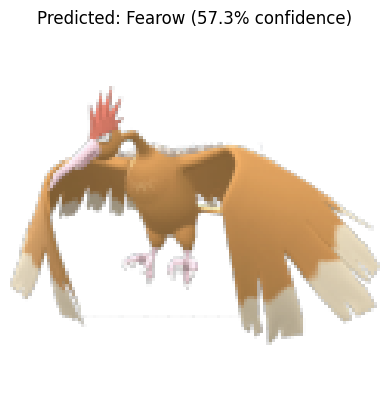

Predicted class: Fearow
Confidence: 57.3%


In [1]:
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications import mobilenet_v2
import tensorflow as tf
import json

# ========= LOAD MODEL & LABELS =========
MODEL_FILENAME = "pokemon_mobilenetv2_final.keras"
LABEL_FILENAME = "pokemon_labels.json"

model = load_model(MODEL_FILENAME)
with open(LABEL_FILENAME, "r") as f:
    labels = json.load(f)

print("Model and labels loaded successfully!")

# ========= SETTINGS =========
IMG_SIZE = (128, 128)

# ========= DEFINE PREPROCESS FUNCTION =========
def central_crop_preprocess(img):
    # img is HWC numpy array in [0,255]
    img = tf.convert_to_tensor(img, dtype=tf.float32)

    # Crop center 70% (adjust if needed)
    img = tf.image.central_crop(img, central_fraction=0.7)

    # Resize to model input
    img = tf.image.resize(img, IMG_SIZE)

    # MobileNetV2 preprocessing (-1 to +1)
    img = mobilenet_v2.preprocess_input(img)

    return img.numpy()

# ========= UPLOAD IMAGE =========
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# ========= LOAD + PREPROCESS IMAGE =========
img = image.load_img(img_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img)
img_array = central_crop_preprocess(img_array)
img_array = np.expand_dims(img_array, axis=0)

# ========= PREDICT =========
predictions = model.predict(img_array)
predicted_index = np.argmax(predictions[0])
predicted_label = labels[predicted_index]
confidence = float(predictions[0][predicted_index] * 100.0)

# ========= DISPLAY =========
plt.imshow(plt.imread(img_path))
plt.axis("off")
plt.title(f"Predicted: {predicted_label} ({confidence:.1f}% confidence)")
plt.show()

print("Predicted class:", predicted_label)
print("Confidence:", f"{confidence:.1f}%")
